# Model 2 - KNN

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import pickle

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score
)

In [3]:
df = pd.read_csv(r"./datasets/Heart_Disease_Indicators.csv")

In [4]:
X = df.drop(['HeartDiseaseorAttack'], axis=1)
y = df['HeartDiseaseorAttack']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.4, random_state=42, stratify=y)

In [6]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(algorithm='brute'))
])


In [7]:
param_dist = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [2] # 2 - Euclidean
}

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [9]:
model = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=12,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

In [10]:
model.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,estimator,Pipeline(step...hm='brute'))])
,param_distributions,"{'knn__n_neighbors': [3, 5, ...], 'knn__p': [2], 'knn__weights': ['uniform', 'distance']}"
,n_iter,12
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [11]:
print("Best params:", model.best_params_)
print("Best CV ROC-AUC:", model.best_score_)

Best params: {'knn__weights': 'uniform', 'knn__p': 2, 'knn__n_neighbors': 31}
Best CV ROC-AUC: 0.8163590187581367


In [12]:
model = model.best_estimator_

In [13]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

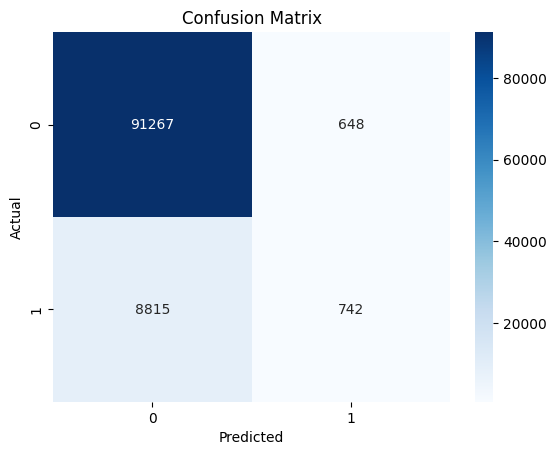

In [14]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

         0.0     0.9119    0.9930    0.9507     91915
         1.0     0.5338    0.0776    0.1356      9557

    accuracy                         0.9067    101472
   macro avg     0.7229    0.5353    0.5431    101472
weighted avg     0.8763    0.9067    0.8739    101472



In [16]:
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))

Test ROC-AUC: 0.8180591727423575


# Pickle File

In [17]:
with open('./model-2.pkl', 'wb') as f:
    pickle.dump(model, f)

In [18]:
with open('./model-1.pkl', 'rb') as f:
    loaded_model = pickle.load(f)